In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from annotation_utils import load_marcotte_subtypes
from common import basedir, evaluations_dir
from embedding_utils import perform_pca_on_embeddings

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

embedding_df = pd.read_csv(evaluations_dir / model / data/ "embeddings_figure1a.csv", index_col=0)

# PCA across jobs
pca_embedding_df, _ = perform_pca_on_embeddings(embedding_df)

subtypes_marcotte = load_marcotte_subtypes(pca_embedding_df.index.unique())


Explained variance for cytof_init BT20: [0.44624721 0.22999238]; Total: 0.6762
Explained variance for cytof_init EVSAT: [0.36258046 0.2586136 ]; Total: 0.6212
Explained variance for cytof_init HCC1500: [0.3855114  0.23499979]; Total: 0.6205
Explained variance for cytof_init HCC2185: [0.43132387 0.20287879]; Total: 0.6342
Explained variance for cytof_init MCF7: [0.40257985 0.348461  ]; Total: 0.7510
Explained variance for cytof_init UACC3199: [0.44968465 0.22886735]; Total: 0.6786
Explained variance for cytof_init UACC893: [0.49689166 0.19530375]; Total: 0.6922
Explained variance for multimodal BT20: [0.47589243 0.23978101]; Total: 0.7157
Explained variance for multimodal EVSAT: [0.48442227 0.21974175]; Total: 0.7042
Explained variance for multimodal HCC1500: [0.3242519  0.26907482]; Total: 0.5933
Explained variance for multimodal HCC2185: [0.51238915 0.22066874]; Total: 0.7331
Explained variance for multimodal MCF7: [0.43770443 0.23070368]; Total: 0.6684
Explained variance for multimod

In [2]:
embedding_df.n_hidden.unique()

array([6])

In [3]:
import numpy as np
pca_embedding_df["subtype_three_receptor"] = subtypes_marcotte["subtype_three_receptor"]
pca_embedding_df["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
pca_embedding_df["hr"] = np.logical_or(
    subtypes_marcotte["status_PGR"] == 'high',
    subtypes_marcotte["status_ESR1"] == 'high'
)
pca_embedding_df["luminalbasal"] = pca_embedding_df["subtype_intrinsic"]
pca_embedding_df["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
pca_embedding_df["luminalbasal"].replace(["CL"], "Basal", inplace=True)

In [4]:
subtypes_marcotte[subtypes_marcotte.index.isin(["cMCF7", "cBT20", "cHCC1500", "cHCC2185", "cEVSAT", "cUACC3199", "cUACC893"])]

,expression_AR,status_AR,expression_ESR1,status_ESR1,expression_ERBB2,status_ERBB2,expression_PGR,status_PGR,subtype_three_receptor,subtype_neve,subtype_claudin_low,subtype_curtis,subtype_intrinsic,subtype_lehmann_tnbc,subtype_marcotte,subtype_rppa,subtype_screen_unsupervised
cell_line,,,,,,,,,,,,,,,,,
cBT20,-3.322,low,0.147,low,4.855,low,-3.322,low,TNBC,basala,other,Intclust10,Basal,LAR,cluster5,rppa4,cluster4
cEVSAT,1.375,high,-3.322,low,6.265,low,2.538,high,ER,luminal,other,Intclust6,HER2,NaN,cluster6,rppa4,cluster6
cHCC1500,4.493,high,6.792,high,5.508,low,3.244,high,ER,luminal,other,Intclust6,LuminalA,NaN,cluster7,rppa8,cluster6
cHCC2185,2.484,high,1.353,low,7.256,low,-3.322,low,TNBC,luminal,other,Intclust10,LuminalB,LAR,cluster6,rppa4,cluster2
cMCF7,0.755,low,6.319,high,5.049,low,4.404,high,ER,luminal,other,Intclust1,LuminalA,NaN,cluster7,rppa8,cluster6
cUACC3199,-1.577,low,-3.322,low,4.474,low,-3.322,low,TNBC,basalb,other,Intclust10,Basal,BL1,cluster3,rppa4,NaN
cUACC893,3.274,high,0.194,low,11.141,high,-3.322,low,ERBB2,her2,other,Intclust5,HER2,NaN,cluster6,rppa7,cluster2


# Embeddings annotated by Luminal/Basal

In [5]:
luminalbasal_colors = {
    "Luminal": "yellow",
    "Basal": "magenta",
    "Normal": "cornflowerblue"
}

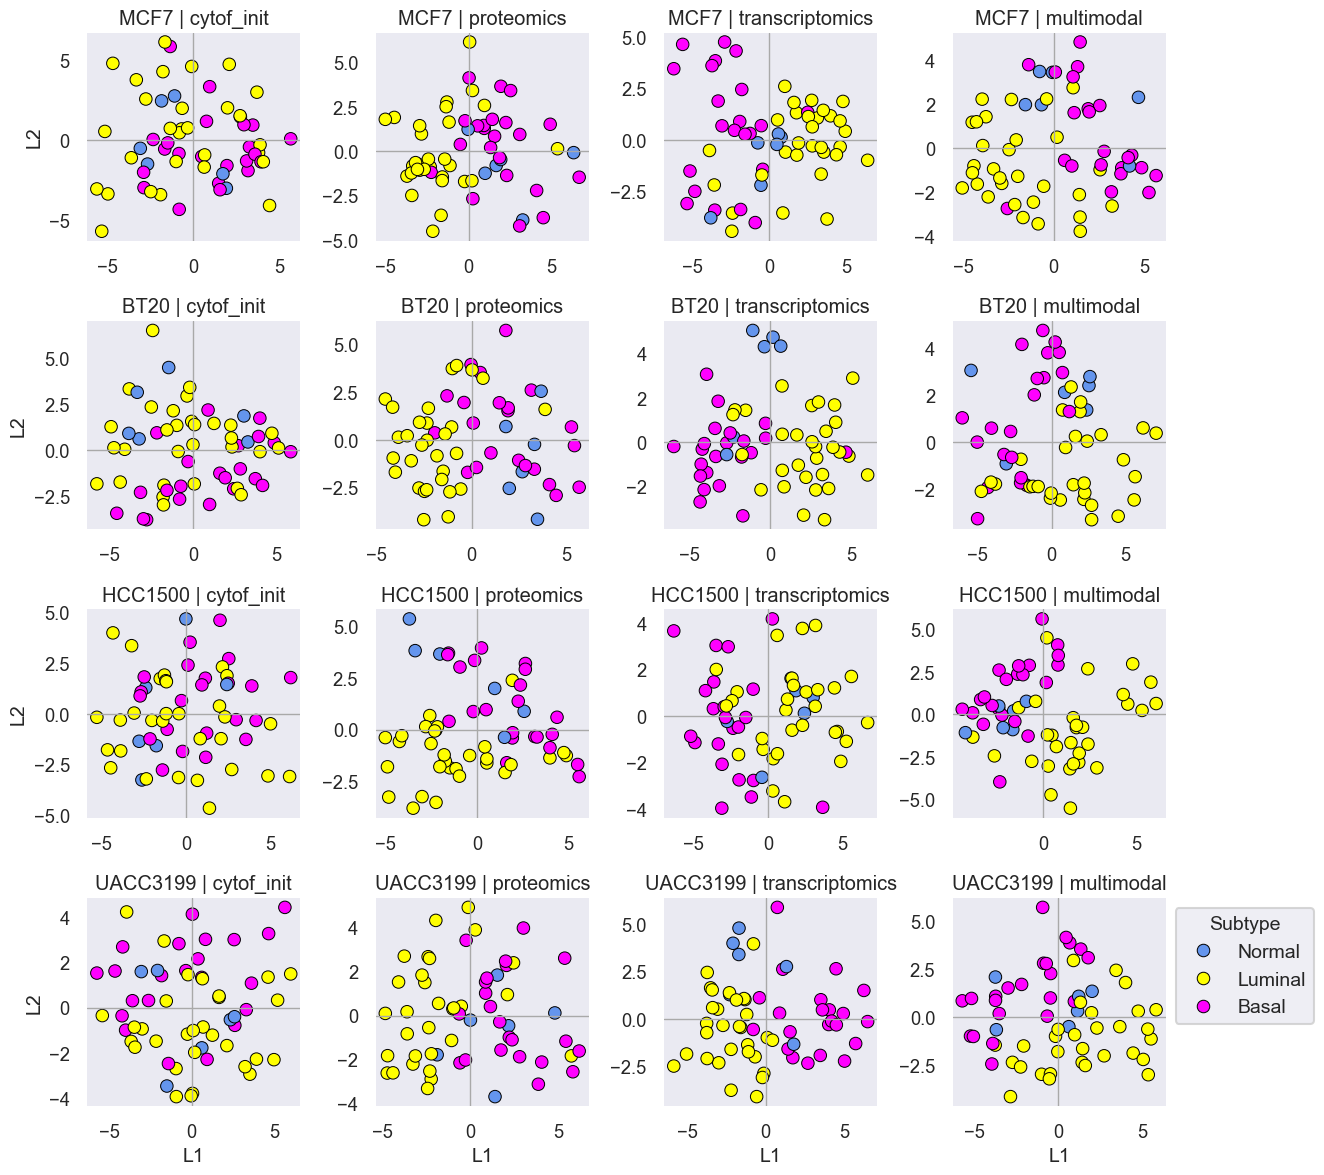

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk", font_scale=0.8)

g = sns.FacetGrid(
    pca_embedding_df[pca_embedding_df.samples.isin(["MCF7", "BT20", "HCC1500", "UACC3199"])],
    row="samples",
    row_order=["MCF7", "BT20", "HCC1500", "UACC3199"],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette=luminalbasal_colors,
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2", fontsize=14)

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="Subtype", bbox_to_anchor=(1, 1), fontsize=14, title_fontsize=14)
plt.show()

# Check association with EGFR transcript levels

In [7]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)
pp38 = cytof_init["p.p38"]
pp38 -= pp38.mean()
pp90rsk = cytof_init["p.p90RSK"]
pp90rsk -= pp90rsk.mean()
pmek = cytof_init["p.MEK"]
pmek -= pmek.mean()
pher2 = cytof_init["p.HER2"]
pher2 -= pher2.mean()
del cytof_init

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
tpls3 = transcriptomics["PLS3"]
tpls3 -= tpls3.mean()
tbtc = transcriptomics["BTC"]
tbtc -= tbtc.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= proteomics.mean()
pisoc1 = proteomics["ISOC1"]
pisoc1 -= pisoc1.mean()
pfasn = proteomics["FASN"]
pfasn -= pfasn.mean()
del proteomics

In [8]:
pca_embedding_df["p.p38"] = pp38.loc[pca_embedding_df.index]
pca_embedding_df["p.p90RSK"] = pp90rsk.loc[pca_embedding_df.index]
pca_embedding_df["p.MEK"] = pmek.loc[pca_embedding_df.index]
pca_embedding_df["p.HER2"] = pher2.loc[pca_embedding_df.index]
pca_embedding_df["tEGFR"] = tegfr.loc[pca_embedding_df.index]
pca_embedding_df["pISOC1"] = pisoc1.loc[pca_embedding_df.index]
pca_embedding_df["pFASN"] = pfasn.loc[pca_embedding_df.index]
pca_embedding_df["tPLS3"] = tpls3.loc[pca_embedding_df.index]
pca_embedding_df["tBTC"] = tbtc.loc[pca_embedding_df.index]

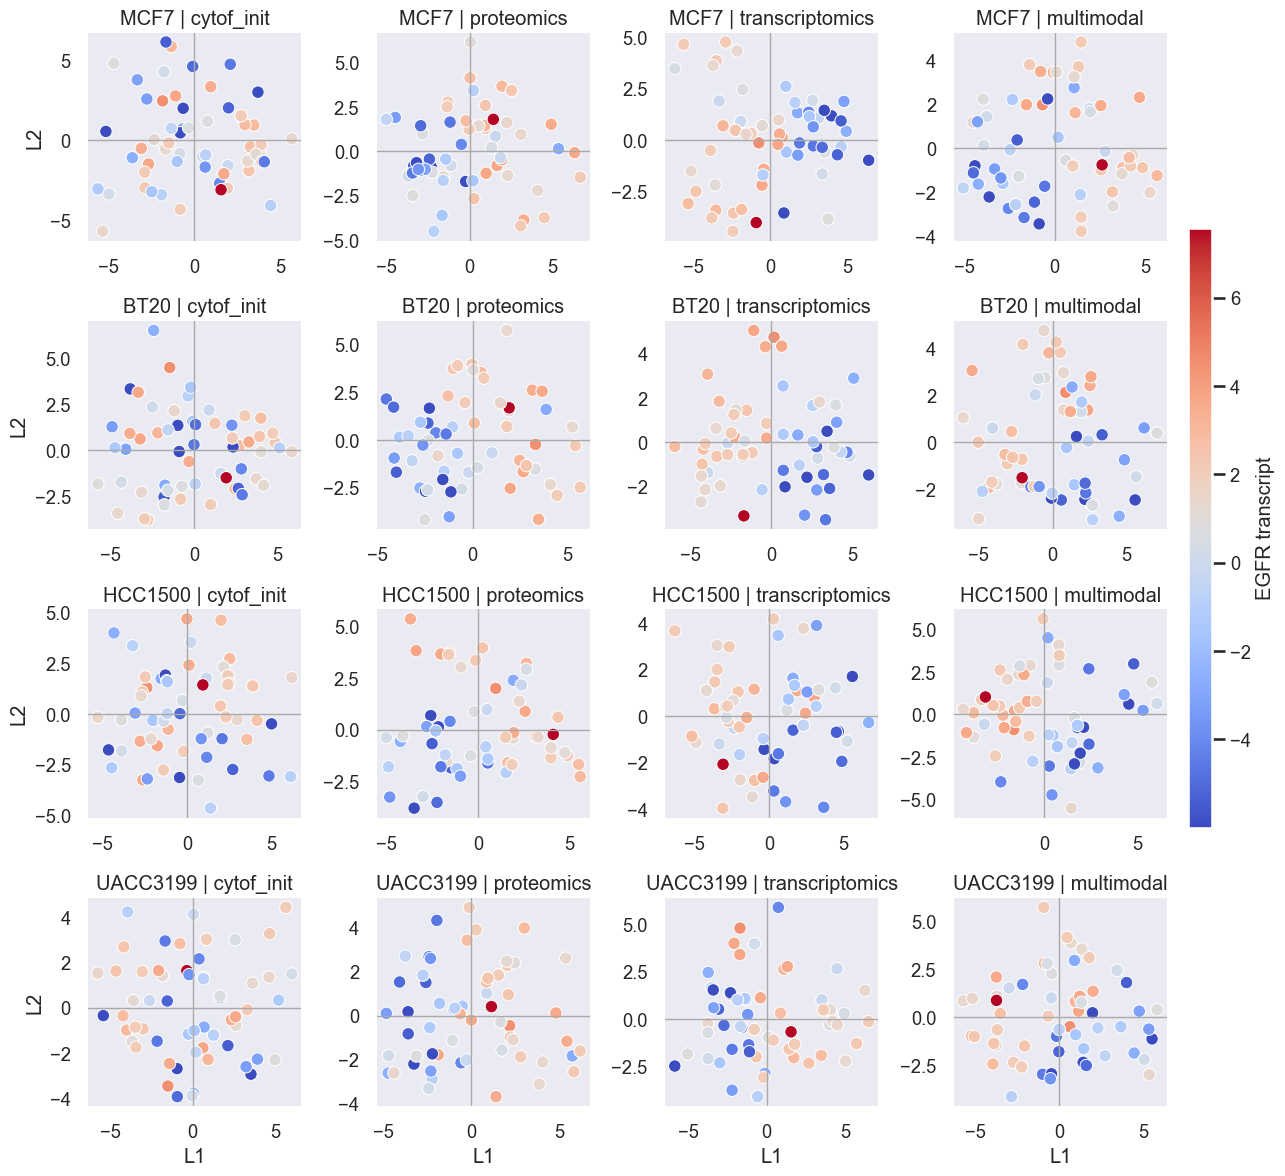

In [9]:
g = sns.FacetGrid(
    pca_embedding_df[pca_embedding_df.samples.isin(["MCF7", "BT20", "HCC1500", "UACC3199"])],
    row="samples",
    row_order=[
        "MCF7",
        "BT20",
        "HCC1500",
        # "EVSAT",
        "UACC3199"
    ],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    sharex=False,
    sharey=False,
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="tEGFR",
    palette="coolwarm",
    # edgecolor="black",
    # size=5,
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Remove the default legend and add a colorbar instead
cax = g.fig.add_axes([1.0, 0.3, 0.02, 0.5])  # [left, bottom, width, height]
norm = plt.Normalize(
    vmin=pca_embedding_df["tEGFR"].min(),
    vmax=pca_embedding_df["tEGFR"].max()
)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
g.fig.colorbar(sm, cax=cax, label="EGFR transcript")
plt.tight_layout()

# Compute most aligned marker in each context/features/split

In [10]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

def top_markers_for_embedding(
    embedding_df: pd.DataFrame,
    tegfr: pd.Series,
    context: str,
    samples: str,
    features_df: pd.DataFrame,
    n_top: int = 1,
    use_tEGFR_axis: bool = False,
):
    """
    Find markers aligned with main and orthogonal directions of embedding.

    Parameters
    ----------
    embedding_df : DataFrame with ['L1','L2','context','samples',index=cell_line]
    tegfr        : Series indexed by cell_line
    context      : which context to filter
    samples      : which CV split
    features_df  : DataFrame with index = cell_line and marker columns
    n_top        : number of top markers to return
    use_tEGFR_axis : if True, define the primary axis by correlation with tEGFR,
                     otherwise use PC1 of embedding
    """
    sub_embed = embedding_df[(embedding_df["context"] == context) &
                             (embedding_df["samples"] == samples)][["L1","L2"]]

    common_idx = sub_embed.index.intersection(features_df.index).intersection(tegfr.index)
    if len(common_idx) < 3:
        return None

    X_embed = sub_embed.loc[common_idx].values
    feats = features_df.loc[common_idx].select_dtypes(include=[np.number])
    t = tegfr.loc[common_idx].values.reshape(-1,1)

    # --- define main / orthogonal axis ---
    if use_tEGFR_axis:
        reg = LinearRegression().fit(X_embed, t)
        main_axis = reg.coef_.ravel()
        main_axis /= np.linalg.norm(main_axis)
        orth_axis = np.array([-main_axis[1], main_axis[0]])  # 90° rotation
    else:
        pca = PCA(n_components=2).fit(X_embed)
        main_axis = pca.components_[0]
        orth_axis = pca.components_[1]

    # project embedding onto axes
    main_scores = X_embed @ main_axis
    orth_scores = X_embed @ orth_axis

    # correlations
    def corr_with_scores(scores):
        return feats.apply(lambda c: np.corrcoef(c.values, scores)[0,1])

    corr_main = corr_with_scores(main_scores).dropna()
    corr_orth = corr_with_scores(orth_scores).dropna()

    top_main = corr_main.abs().sort_values(ascending=False).head(n_top)
    top_orth = corr_orth.abs().sort_values(ascending=False).head(n_top)

    return {
        "context": context,
        "samples": samples,
        "top_main": list(top_main.index),
        "corr_main": list(corr_main.loc[top_main.index]),
        "top_orth": list(top_orth.index),
        "corr_orth": list(corr_orth.loc[top_orth.index]),
    }

In [11]:
import itertools as itt
import numpy as np
from common import FEATURES_OUTFILE
from training_configuration import CONTEXTS_FEATURES_1A, SPLITS

results = []
for (ctx, feats), split in itt.product(CONTEXTS_FEATURES_1A, SPLITS):
    # load features_df as you do already
    features_df = pd.concat([
        pd.read_csv(FEATURES_OUTFILE.format(model=model, data=data,
                                            context=ctx, features=feats,
                                            dataset=ds, samples=split))
        for ds in ["train","val"]
    ]).set_index("preequilibrationConditionId")

    res = top_markers_for_embedding(
        embedding_df=pca_embedding_df,
        tegfr=tegfr,
        context=ctx,
        samples=split,
        features_df=features_df,
        n_top=3,
        use_tEGFR_axis=True  # flip False/True depending on analysis
    )
    if res:
        results.append(res)

pd.DataFrame(results)

,context,samples,top_main,corr_main,top_orth,corr_orth
0,cytof_init,HCC1500,"[IdU, p.p38, p.MKK4]","[0.6051250676234183, 0.4351701186918395, 0.339...","[p.p90RSK, p.ERK, p.S6K]","[-0.9331694809166439, -0.7573946674685319, -0...."
1,cytof_init,EVSAT,"[p.p38, p.MKK4, p.p90RSK]","[0.7220164692477826, 0.7132782469930985, 0.699...","[p.p90RSK, p.ERK, p.S6K]","[0.6851308703786813, 0.6457037337351156, 0.487..."
2,cytof_init,UACC3199,"[p.MKK3.MKK6, p.p90RSK, p.NFkB]","[0.7253407313966664, 0.6848194217432834, 0.664...","[p.MEK, p.p90RSK, p.MKK4]","[0.8604726087416994, 0.6663560561875204, 0.660..."
3,cytof_init,MCF7,"[p.NFkB, p.PLCg2, p.BTK]","[0.719719851622963, 0.6989051299810314, 0.6555...","[p.p90RSK, p.ERK, p.S6K]","[0.8472437219954313, 0.750349761583088, 0.6879..."
4,cytof_init,HCC2185,"[p.p90RSK, p.STAT3, p.ERK]","[0.6984437850285231, 0.6686229712121469, 0.652...","[p.MEK, p.MKK4, p.p90RSK]","[0.8259713043887836, 0.7001824344207493, 0.680..."
5,cytof_init,UACC893,"[p.p90RSK, p.ERK, p.PLCg2]","[0.7544687935813953, 0.7448163257835743, 0.559...","[p.MEK, p.p90RSK, p.p38]","[0.8228940939562241, 0.7867358594847537, 0.777..."
6,cytof_init,BT20,"[p.p90RSK, p.ERK, p.MKK4]","[0.8853634622267302, 0.8304655461172541, 0.656...","[p.MEK, p.HER2, p.p38]","[0.8279911142682564, 0.671965277619979, 0.6490..."
7,proteomics,HCC1500,"[ANLN, CISD3, SLC35A1]","[0.7411626131726367, -0.7317969441918288, -0.6...","[RDH10, TAP2, TRPT1]","[-0.6129244093845073, -0.5202055572377032, 0.5..."
8,proteomics,EVSAT,"[GNE, MTAP, CMBL]","[0.6583389205295348, 0.6543040032986154, -0.63...","[RDH10, BAZ1A, TRPT1]","[0.5770254138520433, 0.43228615672671405, -0.4..."
9,proteomics,UACC3199,"[ANLN, MT1X, PLS3]","[0.769026689398122, 0.7260280711918566, 0.7064...","[SMAD4, BAZ1A, HPDL]","[-0.7943236116531647, 0.639452664794678, 0.462..."


In [12]:
import itertools as itt
import numpy as np
from common import FEATURES_OUTFILE
from training_configuration import CONTEXTS_FEATURES_1A, SPLITS

for (context, features), split in itt.product(CONTEXTS_FEATURES_1A, SPLITS):
    features_df = pd.concat(
        [
            pd.read_csv(FEATURES_OUTFILE.format(model=model, data=data, context=context, features=features, dataset=dataset, samples=split))
            for dataset in ["train", "val"]
        ]
    )
    features_df.set_index("preequilibrationConditionId", inplace=True)
    features_df = features_df.loc[tegfr.index]
    columns = features_df.columns
    corrs = []
    for col in columns:
        corrs.append(np.corrcoef(features_df[col], tegfr.values)[0, 1])
    print(context, features, split, columns[np.argmax(np.abs(corrs))])



cytof_init RFE_15_permute HCC1500 p.MKK3.MKK6
cytof_init RFE_15_permute EVSAT p.4EBP1
cytof_init RFE_15_permute UACC3199 p.MKK3.MKK6
cytof_init RFE_15_permute MCF7 p.4EBP1
cytof_init RFE_15_permute HCC2185 p.MKK3.MKK6
cytof_init RFE_15_permute UACC893 p.4EBP1
cytof_init RFE_15_permute BT20 p.4EBP1
proteomics HVGRFE_10_permute HCC1500 ANLN
proteomics HVGRFE_10_permute EVSAT ANLN
proteomics HVGRFE_10_permute UACC3199 ANLN
proteomics HVGRFE_10_permute MCF7 IL18
proteomics HVGRFE_10_permute HCC2185 ISOC1
proteomics HVGRFE_10_permute UACC893 ELAPOR1
proteomics HVGRFE_10_permute BT20 SP100
transcriptomics HVGRFE_15_permute HCC1500 PLS3
transcriptomics HVGRFE_15_permute EVSAT CALD1
transcriptomics HVGRFE_15_permute UACC3199 CALD1
transcriptomics HVGRFE_15_permute MCF7 FSTL1
transcriptomics HVGRFE_15_permute HCC2185 PLS3
transcriptomics HVGRFE_15_permute UACC893 FOXA1
transcriptomics HVGRFE_15_permute BT20 FSTL1
multimodal RFE_10_permute HCC1500 pANLN
multimodal RFE_10_permute EVSAT pANLN
mult

# phospho-p90RSK - orthogonal direction of variation in multimodal + other contexts!

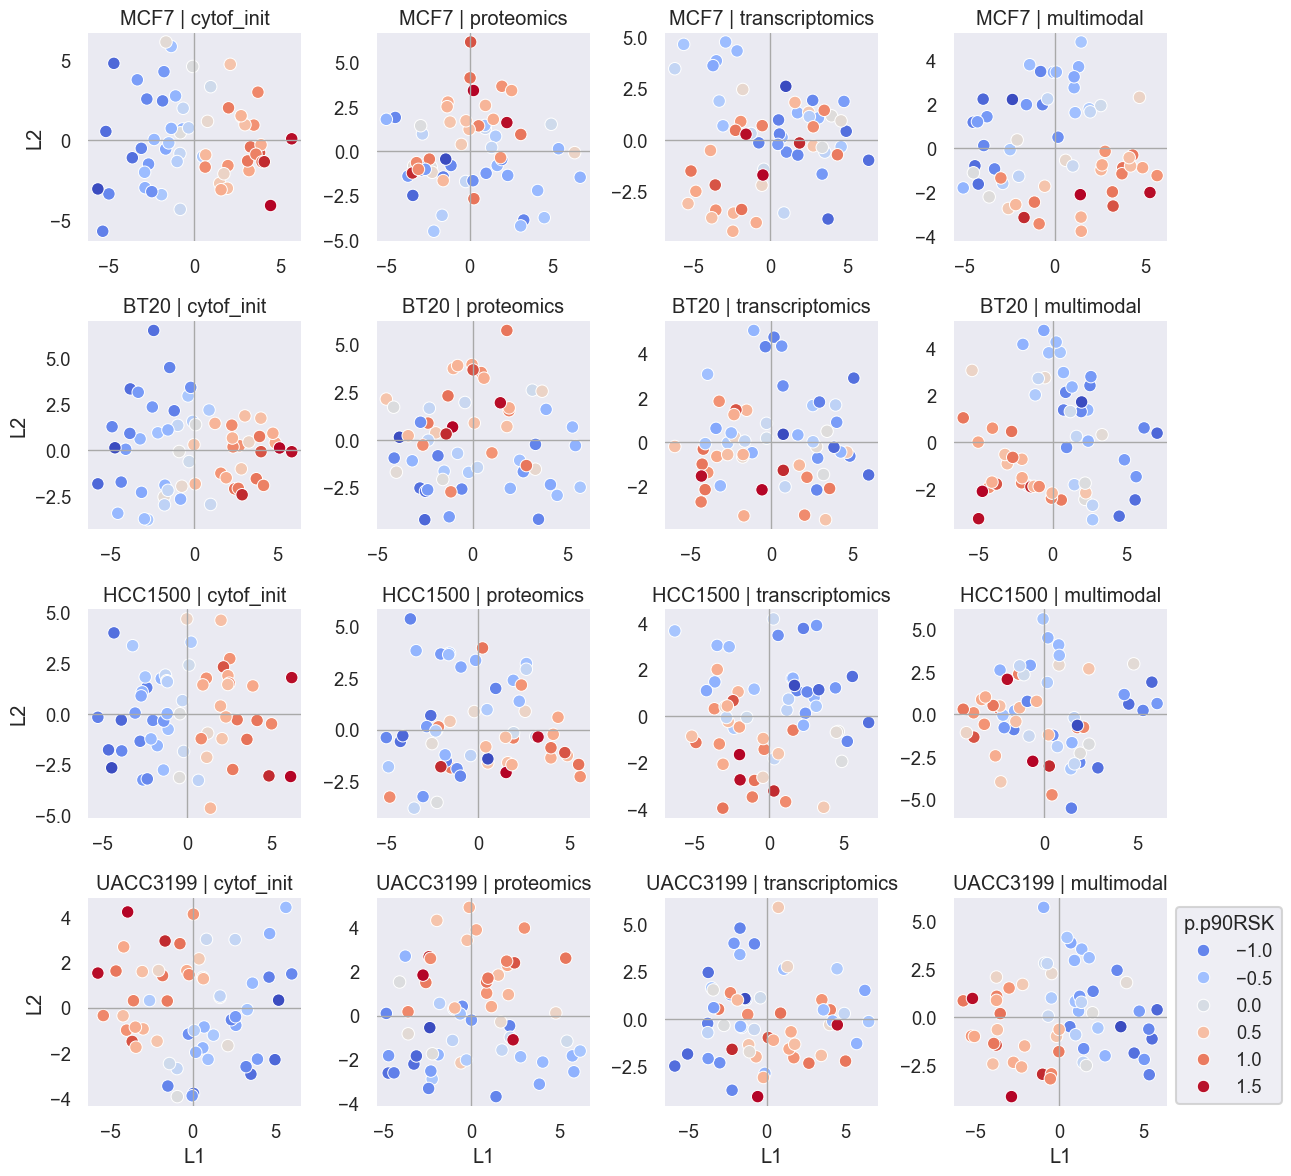

In [13]:
g = sns.FacetGrid(
    pca_embedding_df[pca_embedding_df.samples.isin(["MCF7", "BT20", "HCC1500", "UACC3199"])],
    row="samples",
    row_order=["MCF7", "BT20", "HCC1500", "UACC3199"],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="p.p90RSK", bbox_to_anchor=(1, 1))
plt.show()

cytof_init 0.2353552532123961


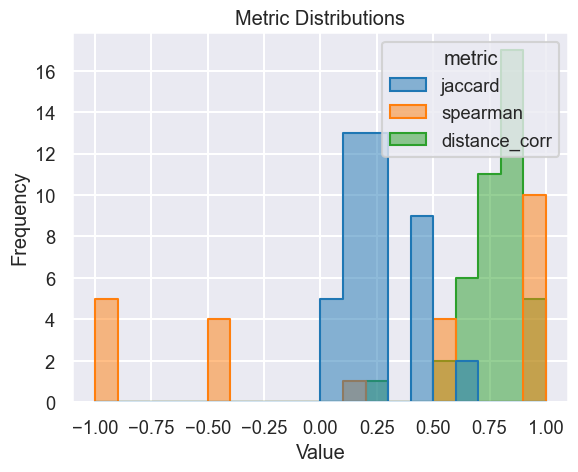

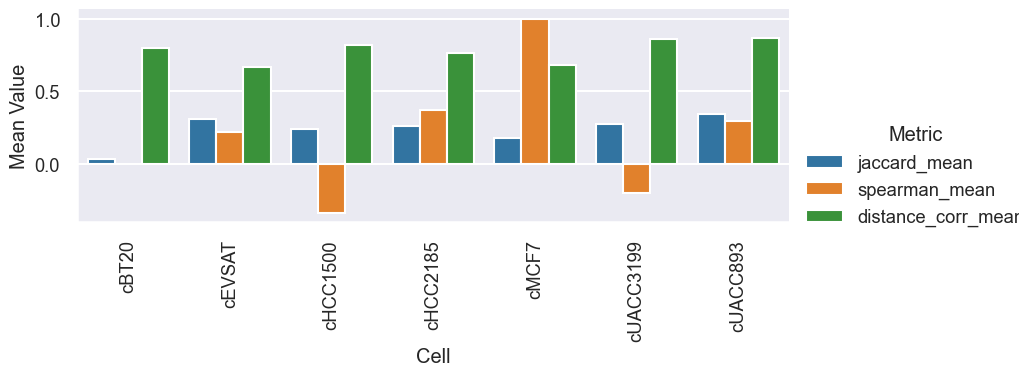

multimodal 0.2193877551020408


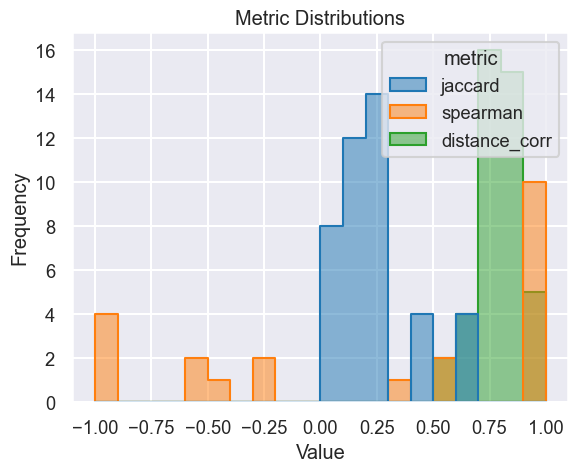

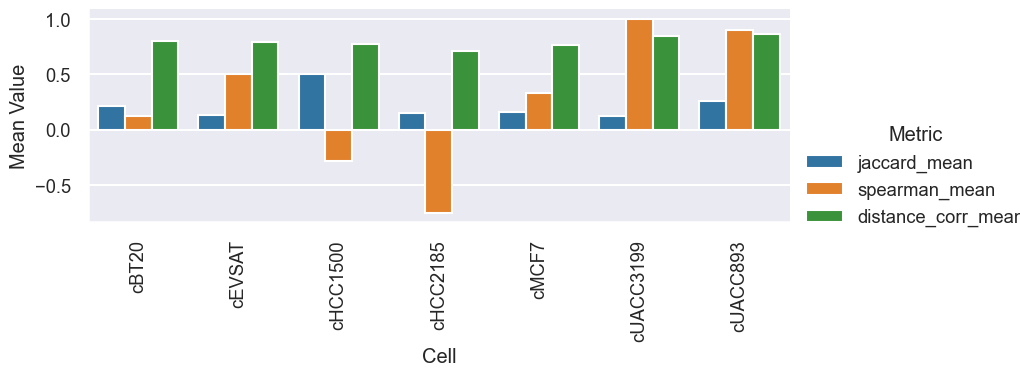

proteomics 0.1598639455782313


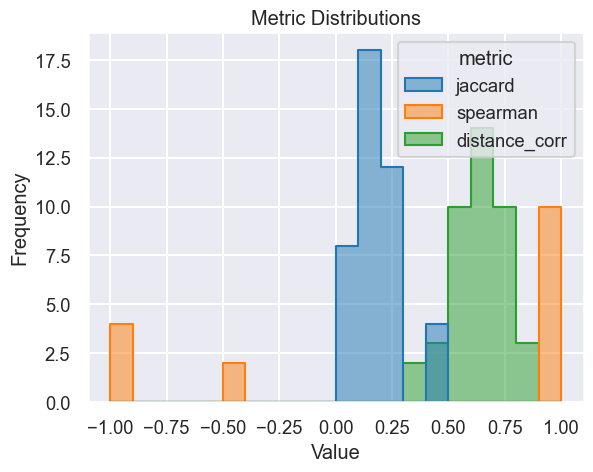

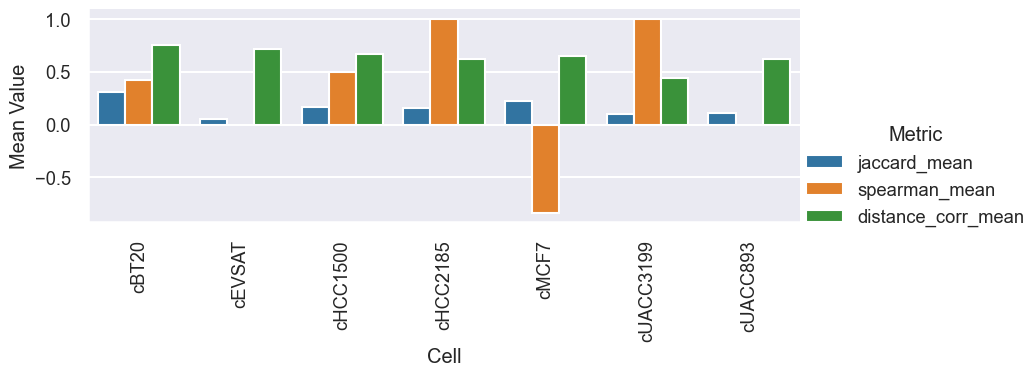

transcriptomics 0.1225434618291761


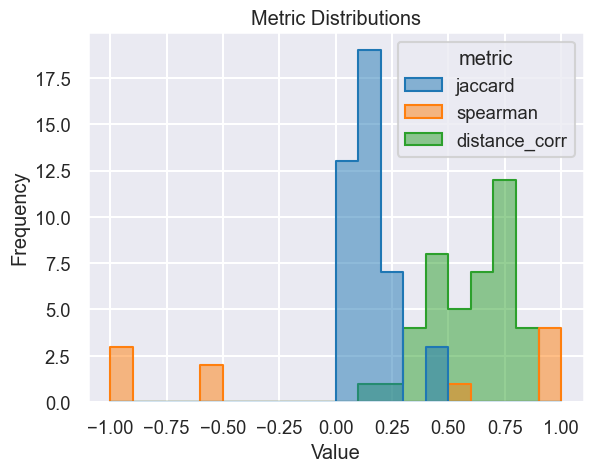

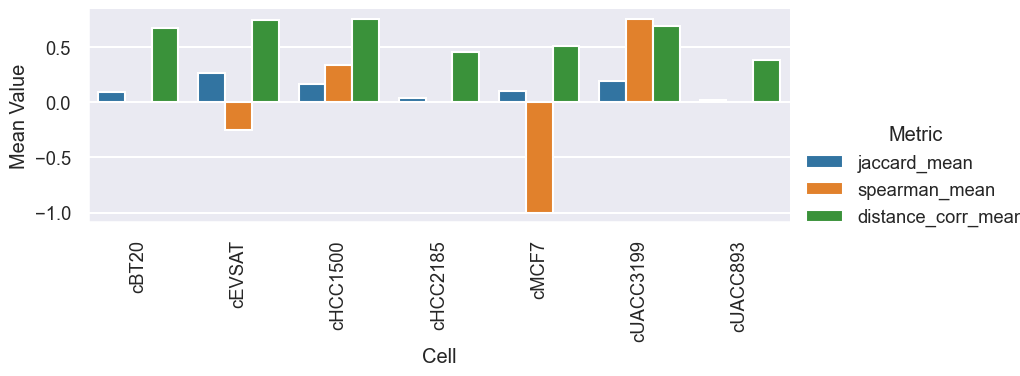

In [14]:
from embedding_consistency import *

# Compute per (split vs other_split) comparisons for each validation cell
splits = ["MCF7", "BT20", "HCC1500", "HCC2185", "EVSAT", "UACC3199", "UACC893"]
summaries = []
for context in sorted(pca_embedding_df.context.unique()):
    per_pair = compute_validation_neighborhood_consistency(
        {split: pca_embedding_df[(pca_embedding_df["samples"] == split) & (pca_embedding_df.context == context)][["L1", "L2"]] for split in splits},
        {split: "c"+split for split in splits},
        n_neighbors=5,      # set N here
        metric="euclidean",  # or "cosine"
    )

    # Summaries per cell
    summary = summarize_consistency(per_pair)
    print(context, summary.jaccard_mean.mean())
    summaries.append(summary.assign(model=model, context=context))

    plot_distribution(per_pair)
    plot_per_cell_summary(summary)

overall_summary = pd.concat(summaries)

In [15]:
overall_summary.groupby(["model", "context"]).agg({"jaccard_mean": "mean", "spearman_mean": "mean", "distance_corr_mean": "mean"})

jaccard_mean  spearman_mean  \
model             context                                        
EGFR_MAPK__logobs cytof_init           0.235355       0.226944   
                  multimodal           0.219388       0.261190   
                  proteomics           0.159864       0.416667   
                  transcriptomics      0.122543      -0.041667   

                                   distance_corr_mean  
model             context                              
EGFR_MAPK__logobs cytof_init                 0.780456  
                  multimodal                 0.793300  
                  proteomics                 0.638547  
                  transcriptomics            0.597158

Text(0.5, 40.60000000000001, 'Context')

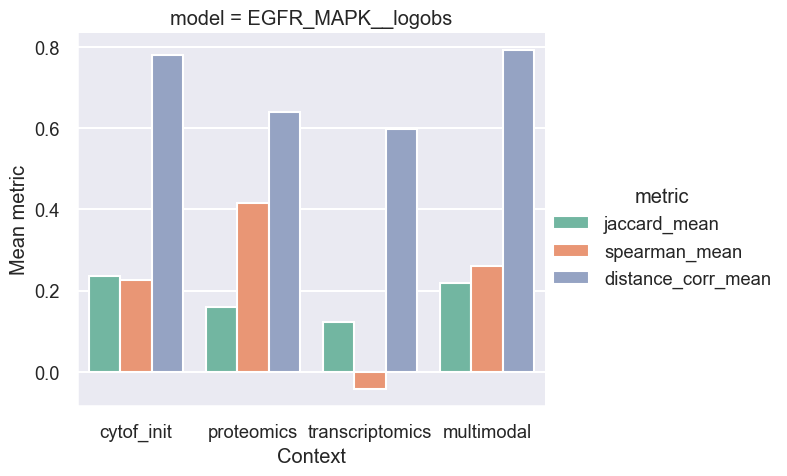

In [16]:
import matplotlib.pyplot as plt

agg_df = overall_summary.groupby(["model", "context"]).agg({
    "jaccard_mean": "mean",
    "spearman_mean": "mean",
    "distance_corr_mean": "mean"
}).reset_index()

melted = agg_df.melt(
    id_vars=["model", "context"],
    value_vars=["jaccard_mean", "spearman_mean", "distance_corr_mean"],
    var_name="metric", value_name="mean_value"
)

sns.catplot(
    data=melted,
    x="context",
    order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    y="mean_value",
    hue="metric",
    col="model",
    kind="bar",
    palette="Set2",
    height=5,
    aspect=1.2
)
plt.ylabel("Mean metric")
plt.xlabel("Context")

Weirdly enough, multimodal seems to display less embedding consistency compared to cytof_init? Both are, unsurprisingly, better than proteomics and transcriptomics